In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
#  paleta 
BLUE   = "#2563EB"
ORANGE = "#F97316"
RED    = "#EF4444"
GREEN  = "#22C55E"
PURPLE = "#A855F7"
GRAY   = "#6B7280"
BG     = "#F8FAFC"
DARK   = "#1E293B"
 
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   DARK,
    "axes.labelcolor":  DARK,
    "xtick.color":      DARK,
    "ytick.color":      DARK,
    "text.color":       DARK,
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
 

In [3]:
#  dados 
df = pd.read_csv("../data/train.csv")
print(f"Shape: {df.shape}")

Shape: (1460, 81)


In [4]:

# PARTE 1 – REGRAS DE ASSOCIAÇÃO
 
# Binarização de features categóricas e numéricas
def binarize(df):
    items = []
    # Qualidade geral
    items.append(("HighQual",    df["OverallQual"] >= 7))
    items.append(("LowQual",     df["OverallQual"] <= 4))
    # Preço (target)
    q33 = df["SalePrice"].quantile(0.33)
    q66 = df["SalePrice"].quantile(0.66)
    items.append(("PriceHigh",   df["SalePrice"] >= q66))
    items.append(("PriceMid",    (df["SalePrice"] >= q33) & (df["SalePrice"] < q66)))
    items.append(("PriceLow",    df["SalePrice"] < q33))
    # Garagem
    items.append(("HasGarage",   df["GarageArea"] > 0))
    items.append(("BigGarage",   df["GarageArea"] >= 600))
    # Porão
    items.append(("HasBsmt",     df["TotalBsmtSF"] > 0))
    items.append(("BigBsmt",     df["TotalBsmtSF"] >= 1000))
    # Área
    items.append(("BigHouse",    df["GrLivArea"] >= 2000))
    items.append(("SmallHouse",  df["GrLivArea"] < 1200))
    # Banheiros
    items.append(("MultiBath",   df["FullBath"] >= 2))
    # Lareira
    items.append(("HasFireplace",df["Fireplaces"] > 0))
    # Ar condicionado
    items.append(("CentralAC",   df["CentralAir"] == "Y"))
    # Cozinha boa
    items.append(("GoodKitchen", df["KitchenQual"].isin(["Gd","Ex"])))
    # Reforma recente
    items.append(("Remodeled",   df["YearRemodAdd"] > df["YearBuilt"]))
    items.append(("NewHouse",    df["YearBuilt"] >= 2000))
    # Bairro premium (top 5 por mediana de preço)
    top_nb = df.groupby("Neighborhood")["SalePrice"].median().nlargest(5).index
    items.append(("PremiumNbhd", df["Neighborhood"].isin(top_nb)))
    # Paved driveway
    items.append(("PavedDrive",  df["PavedDrive"] == "Y"))
    
    result = pd.DataFrame({name: series.astype(bool) for name, series in items})
    return result
 
bin_df = binarize(df)
print("Binarized shape:", bin_df.shape)
print("Features:", list(bin_df.columns))
 
# Apriori
freq_items = apriori(bin_df, min_support=0.05, use_colnames=True, max_len=3)
rules = association_rules(freq_items, metric="lift", min_threshold=1.2)
rules = rules.sort_values("lift", ascending=False)
print(f"\nTotal rules: {len(rules)}")
print(rules[["antecedents","consequents","support","confidence","lift"]].head(10).to_string())

Binarized shape: (1460, 19)
Features: ['HighQual', 'LowQual', 'PriceHigh', 'PriceMid', 'PriceLow', 'HasGarage', 'BigGarage', 'HasBsmt', 'BigBsmt', 'BigHouse', 'SmallHouse', 'MultiBath', 'HasFireplace', 'CentralAC', 'GoodKitchen', 'Remodeled', 'NewHouse', 'PremiumNbhd', 'PavedDrive']

Total rules: 1728
                             antecedents                         consequents   support  confidence      lift
1103              frozenset({BigGarage})  frozenset({BigHouse, PremiumNbhd})  0.051370    0.232198  3.988345
1102  frozenset({BigHouse, PremiumNbhd})              frozenset({BigGarage})  0.051370    0.882353  3.988345
1219            frozenset({PremiumNbhd})    frozenset({NewHouse, BigGarage})  0.088356    0.483146  3.752092
1218    frozenset({NewHouse, BigGarage})            frozenset({PremiumNbhd})  0.088356    0.686170  3.752092
1100    frozenset({BigHouse, BigGarage})            frozenset({PremiumNbhd})  0.051370    0.635593  3.475528
1105            frozenset({PremiumNbhd})   

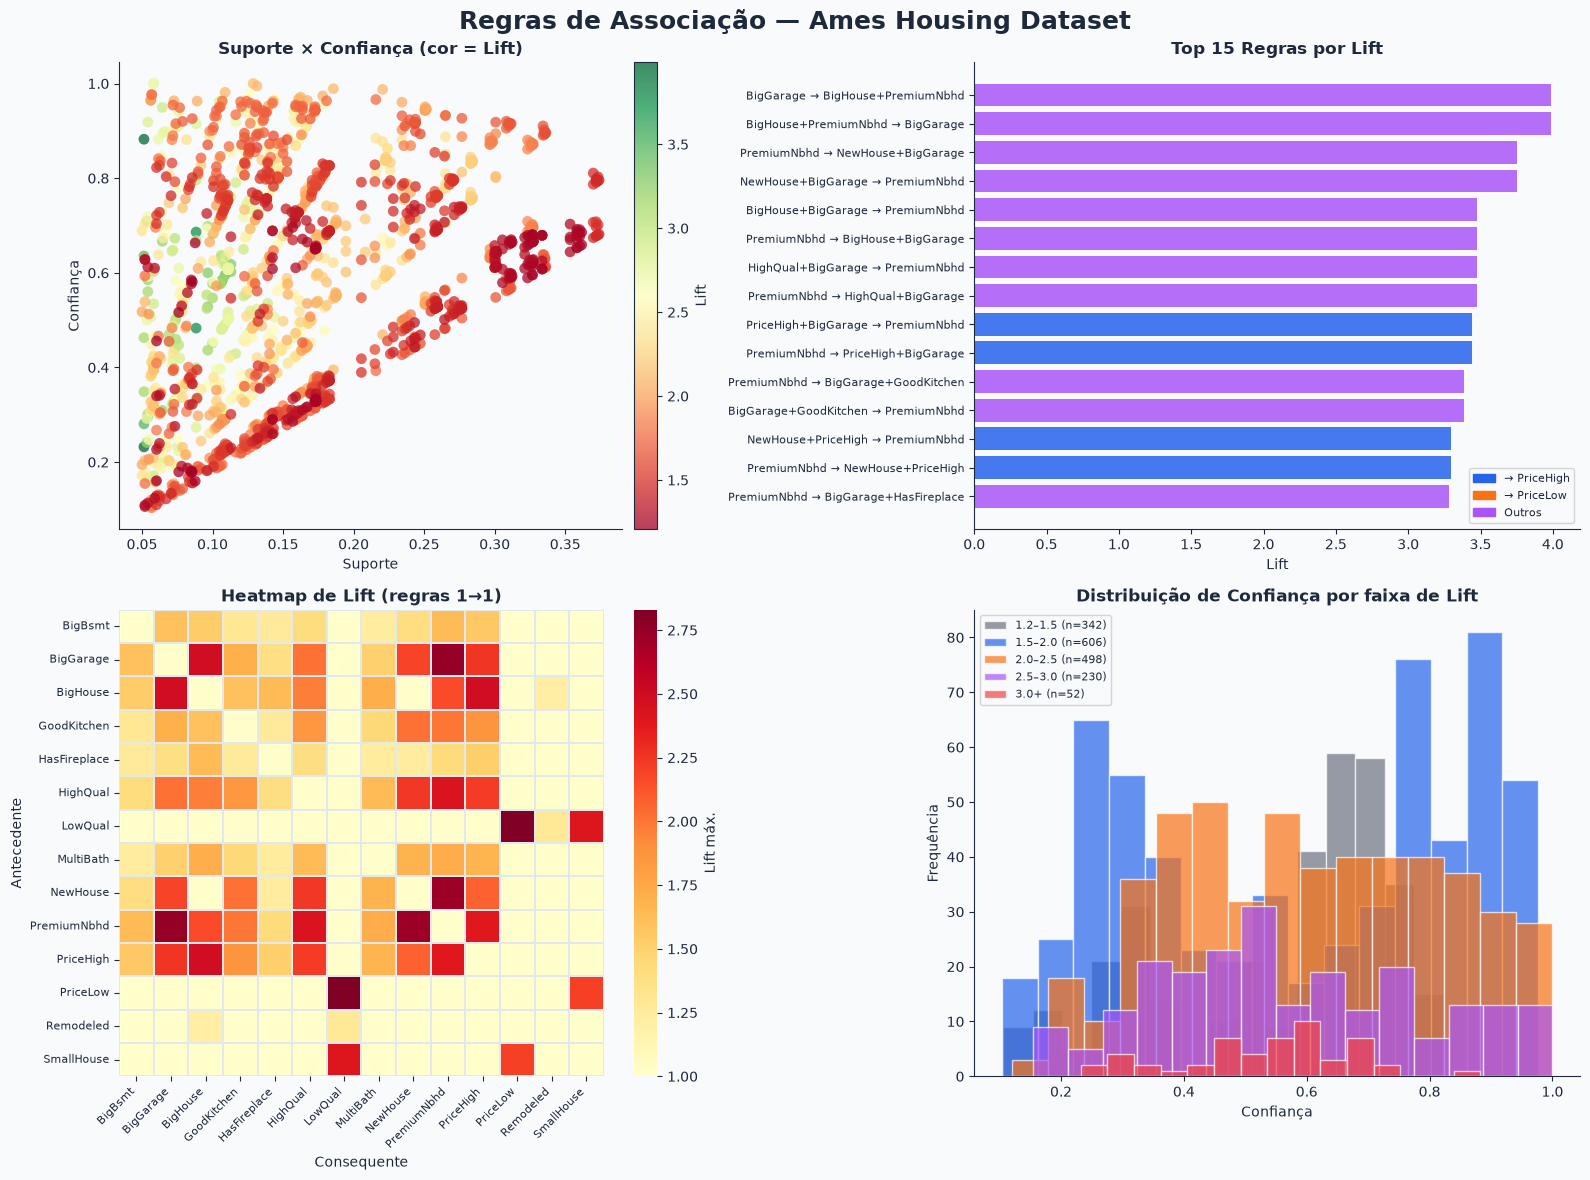

Fig 1 salva.


In [5]:
# FIGURA 1 – REGRAS DE ASSOCIAÇÃO
import os
os.makedirs("outputs", exist_ok=True)

fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle("Regras de Associação — Ames Housing Dataset", fontsize=18, fontweight="bold", y=0.98)

# 1a) Scatter Support × Confidence (colorido por Lift)
ax = axes[0,0]
sc = ax.scatter(rules["support"], rules["confidence"],
                c=rules["lift"], cmap="RdYlGn", s=60, alpha=0.75, edgecolors="none")
cb = fig1.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("Lift", fontsize=10)
ax.set_xlabel("Suporte")
ax.set_ylabel("Confiança")
ax.set_title("Suporte × Confiança (cor = Lift)", fontweight="bold")

# 1b) Top 15 regras por lift (barras horizontais)
ax = axes[0,1]
top15 = rules.head(15).copy()
top15["rule"] = [f"{list(a)[0] if len(a)==1 else '+'.join(list(a)[:2])} → {list(c)[0] if len(c)==1 else '+'.join(list(c)[:2])}"
                 for a, c in zip(top15["antecedents"], top15["consequents"])]
colors = [BLUE if "PriceHigh" in r else ORANGE if "PriceLow" in r else PURPLE for r in top15["rule"]]
bars = ax.barh(range(len(top15)), top15["lift"], color=colors, alpha=0.85)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["rule"], fontsize=8)
ax.set_xlabel("Lift")
ax.set_title("Top 15 Regras por Lift", fontweight="bold")
ax.invert_yaxis()
from matplotlib.patches import Patch
legend_elements = [Patch(color=BLUE, label="→ PriceHigh"),
                   Patch(color=ORANGE, label="→ PriceLow"),
                   Patch(color=PURPLE, label="Outros")]
ax.legend(handles=legend_elements, fontsize=8)

# 1c) Heatmap: features como antecedentes vs consequentes (lift médio)
ax = axes[1,0]
simple = rules[rules["antecedents"].apply(len)==1 & (rules["consequents"].apply(len)==1)].copy()
simple["ant_str"] = simple["antecedents"].apply(lambda x: list(x)[0])
simple["con_str"] = simple["consequents"].apply(lambda x: list(x)[0])
pivot = simple.pivot_table(index="ant_str", columns="con_str", values="lift", aggfunc="max")
pivot = pivot.fillna(1.0)
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", linewidths=0.3, linecolor="#e2e8f0",
            cbar_kws={"label":"Lift máx."}, vmin=1)
ax.set_title("Heatmap de Lift (regras 1→1)", fontweight="bold")
ax.set_xlabel("Consequente")
ax.set_ylabel("Antecedente")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)

# 1d) Distribuição de Confidence por faixa de Lift
ax = axes[1,1]
bins_lift = [1.2, 1.5, 2.0, 2.5, 3.0, rules["lift"].max()+0.1]
labels_lift = ["1.2–1.5","1.5–2.0","2.0–2.5","2.5–3.0","3.0+"]
rules["lift_bin"] = pd.cut(rules["lift"], bins=bins_lift, labels=labels_lift)
palette = {l: c for l, c in zip(labels_lift, [GRAY, BLUE, ORANGE, PURPLE, RED])}
for lbl in labels_lift:
    subset = rules[rules["lift_bin"]==lbl]["confidence"]
    if len(subset):
        ax.hist(subset, bins=15, alpha=0.7, label=f"{lbl} (n={len(subset)})",
                color=palette[lbl], edgecolor="white")
ax.set_xlabel("Confiança")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição de Confiança por faixa de Lift", fontweight="bold")
ax.legend(fontsize=8)

fig1.tight_layout()
fig1.savefig("../plots/associacao_regras.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 1 salva.")

In [6]:
# PARTE 2 – LOF (DETECÇÃO DE OUTLIERS)
# ════════════════════════════════════════════════════════════════
 
# Features numéricas para LOF
num_cols = ["GrLivArea","TotalBsmtSF","GarageArea","LotArea",
            "OverallQual","OverallCond","YearBuilt","SalePrice",
            "1stFlrSF","TotRmsAbvGrd","Fireplaces","GarageCars"]
X = df[num_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = lof.fit_predict(X_scaled)          # -1 = outlier
scores = -lof.negative_outlier_factor_      # LOF score (maior = mais anômalo)
 
df["lof_score"] = scores
df["is_outlier"] = labels == -1
n_out = df["is_outlier"].sum()
print(f"\nOutliers detectados: {n_out} ({100*n_out/len(df):.1f}%)")
print(df[df["is_outlier"]][["GrLivArea","SalePrice","OverallQual","lof_score"]].sort_values("lof_score",ascending=False).head(10).to_string())
 


Outliers detectados: 73 (5.0%)
      GrLivArea  SalePrice  OverallQual  lof_score
1298       5642     160000           10   4.247367
313        2036     375000            7   4.154348
335        1786     228950            5   3.384335
249        2144     277000            6   3.281314
53         1842     385000            9   2.616168
523        4676     184750           10   2.579498
332        1629     284000            8   2.552123
706        1824     302000            7   2.507429
1190       1622     168000            4   2.451002
1340        872     123000            4   2.201321


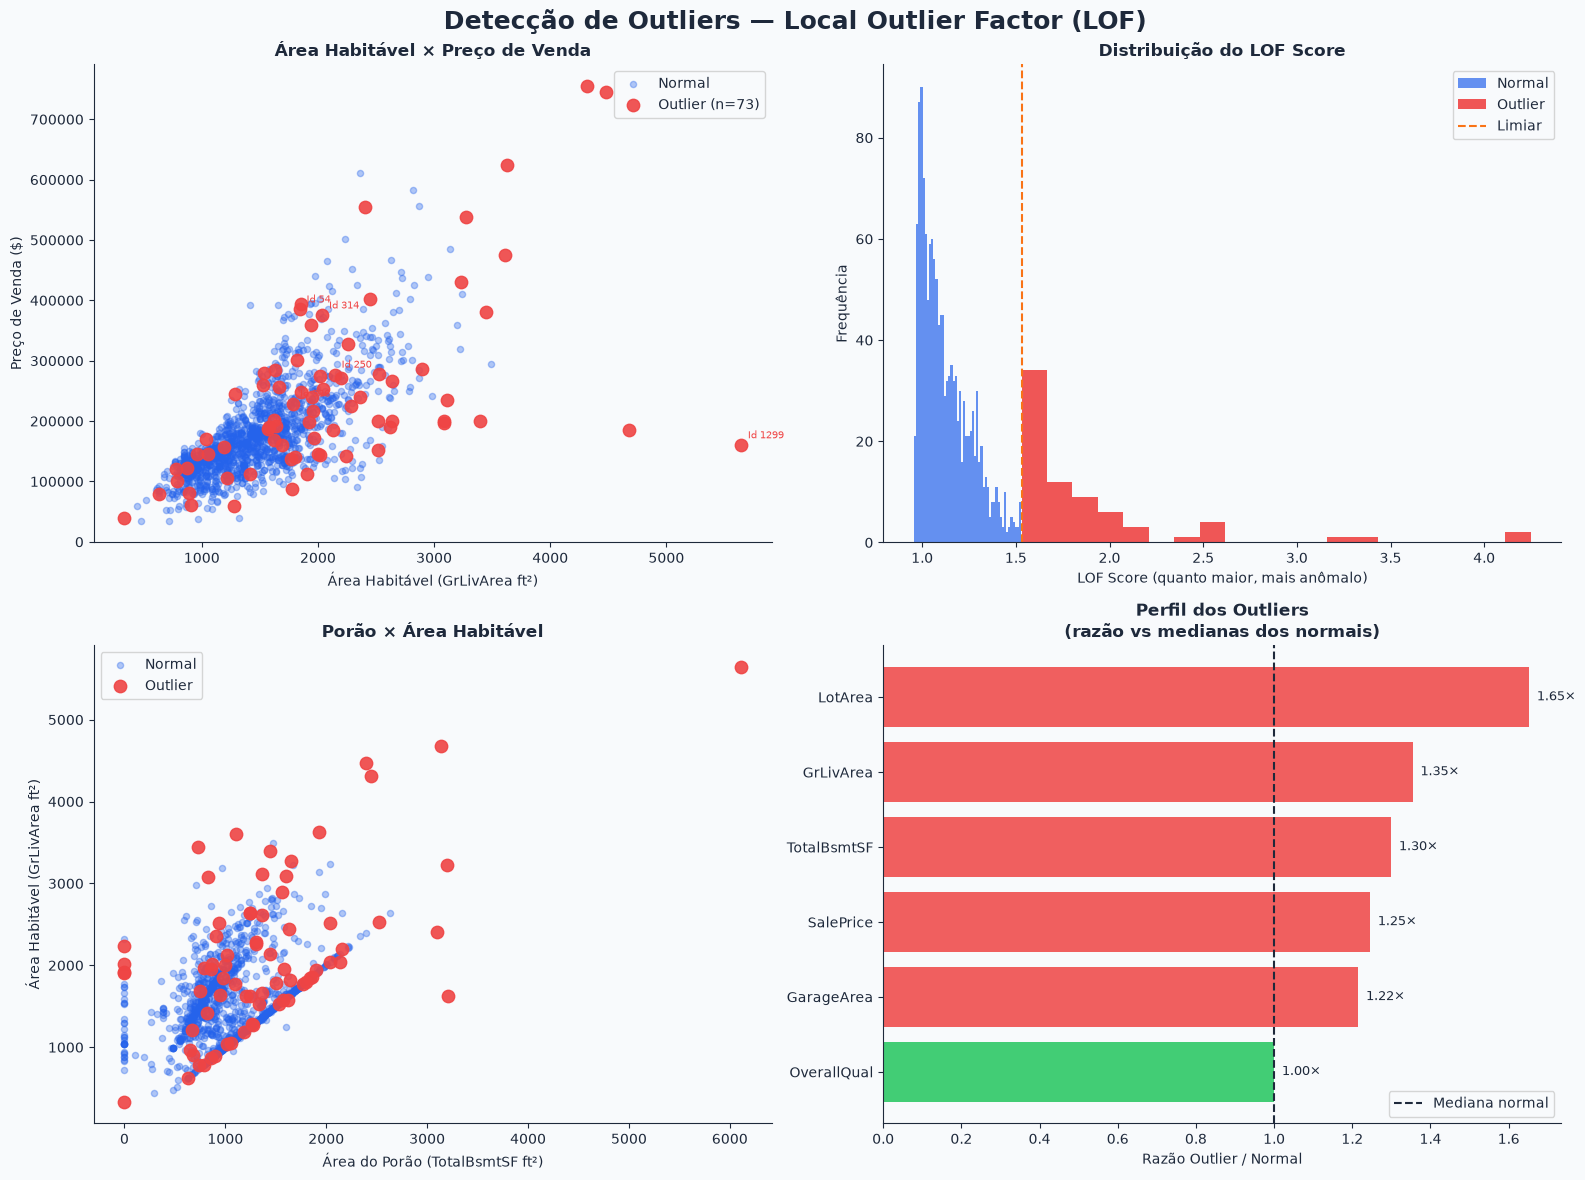

In [7]:



# ── FIGURA 2 – OUTLIERS LOF ──────────────────────────────────────
fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Detecção de Outliers — Local Outlier Factor (LOF)", fontsize=18, fontweight="bold", y=0.98)

colors_pt = [RED if o else BLUE for o in df["is_outlier"]]
sizes_pt  = [80 if o else 20 for o in df["is_outlier"]]
alphas_pt = [0.9 if o else 0.4 for o in df["is_outlier"]]

normal  = df[~df["is_outlier"]]
outlier = df[df["is_outlier"]]

# 2a) GrLivArea vs SalePrice
ax = axes[0,0]
ax.scatter(normal["GrLivArea"],  normal["SalePrice"],  s=20, alpha=0.35, color=BLUE, label="Normal")
ax.scatter(outlier["GrLivArea"], outlier["SalePrice"], s=80, alpha=0.9,  color=RED,  label=f"Outlier (n={n_out})", zorder=5)
ax.set_xlabel("Área Habitável (GrLivArea ft²)")
ax.set_ylabel("Preço de Venda ($)")
ax.set_title("Área Habitável × Preço de Venda", fontweight="bold")
ax.legend()
top5 = outlier.nlargest(5, "lof_score")
for _, row in top5.iterrows():
    ax.annotate(f"Id {int(row['Id'])}", xy=(row["GrLivArea"], row["SalePrice"]),
                fontsize=7, color=RED, xytext=(5,5), textcoords="offset points")

# 2b) Distribuição do LOF score
ax = axes[0,1]
ax.hist(normal["lof_score"],  bins=50, color=BLUE, alpha=0.7, label="Normal")
ax.hist(outlier["lof_score"], bins=20, color=RED,  alpha=0.9, label="Outlier")
ax.axvline(outlier["lof_score"].min(), color=ORANGE, ls="--", lw=1.5, label="Limiar")
ax.set_xlabel("LOF Score (quanto maior, mais anômalo)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição do LOF Score", fontweight="bold")
ax.legend()

# 2c) TotalBsmtSF vs GrLivArea
ax = axes[1,0]
ax.scatter(normal["TotalBsmtSF"],  normal["GrLivArea"],  s=20, alpha=0.35, color=BLUE, label="Normal")
ax.scatter(outlier["TotalBsmtSF"], outlier["GrLivArea"], s=80, alpha=0.9,  color=RED,  label="Outlier", zorder=5)
ax.set_xlabel("Área do Porão (TotalBsmtSF ft²)")
ax.set_ylabel("Área Habitável (GrLivArea ft²)")
ax.set_title("Porão × Área Habitável", fontweight="bold")
ax.legend()

# 2d) Perfil comparativo
ax = axes[1,1]
feat_compare = ["GrLivArea","TotalBsmtSF","GarageArea","LotArea","OverallQual","SalePrice"]
med_norm = normal[feat_compare].median()
med_out  = outlier[feat_compare].median()
ratio = (med_out / med_norm).sort_values()
colors_bar = [RED if r > 1.2 or r < 0.8 else GREEN for r in ratio]
bars = ax.barh(ratio.index, ratio.values, color=colors_bar, alpha=0.85)
ax.axvline(1.0, color=DARK, ls="--", lw=1.5, label="Mediana normal")
ax.set_xlabel("Razão Outlier / Normal")
ax.set_title("Perfil dos Outliers\n(razão vs medianas dos normais)", fontweight="bold")
ax.legend()
for bar, val in zip(bars, ratio.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}×", va="center", fontsize=9)

fig2.tight_layout()
plt.show()

In [8]:
# 2b) LOF score – distribuição
ax = axes[0,1]
ax.hist(df[~df["is_outlier"]]["lof_score"], bins=50, color=BLUE, alpha=0.7, label="Normal")
ax.hist(df[df["is_outlier"]]["lof_score"],  bins=20, color=RED,  alpha=0.9, label="Outlier")
ax.axvline(df[df["is_outlier"]]["lof_score"].min(), color=ORANGE, ls="--", lw=1.5, label="Limiar")
ax.set_xlabel("LOF Score (quanto maior, mais anômalo)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição do LOF Score", fontweight="bold")
ax.legend()
 
# 2c) TotalBsmtSF vs GrLivArea
ax = axes[1,0]
ax.scatter(normal["TotalBsmtSF"],  normal["GrLivArea"],  s=20, alpha=0.35, color=BLUE, label="Normal")
ax.scatter(outlier["TotalBsmtSF"], outlier["GrLivArea"], s=80, alpha=0.9,  color=RED,  label="Outlier", zorder=5)
ax.set_xlabel("Área do Porão (TotalBsmtSF ft²)")
ax.set_ylabel("Área Habitável (GrLivArea ft²)")
ax.set_title("Porão × Área Habitável", fontweight="bold")
ax.legend()
 
# 2d) Perfil comparativo: mediana das features (outlier vs normal)
ax = axes[1,1]
feat_compare = ["GrLivArea","TotalBsmtSF","GarageArea","LotArea","OverallQual","SalePrice"]
med_norm = df[~df["is_outlier"]][feat_compare].median()
med_out  = df[ df["is_outlier"]][feat_compare].median()
# Normalizar pela mediana dos normais
ratio = (med_out / med_norm).sort_values()
colors_bar = [RED if r > 1.2 or r < 0.8 else GREEN for r in ratio]
bars = ax.barh(ratio.index, ratio.values, color=colors_bar, alpha=0.85)
ax.axvline(1.0, color=DARK, ls="--", lw=1.5, label="Mediana normal")
ax.set_xlabel("Razão Outlier / Normal")
ax.set_title("Perfil dos Outliers\n(razão vs medianas dos normais)", fontweight="bold")
ax.legend()
for bar, val in zip(bars, ratio.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}×", va="center", fontsize=9, color=DARK)
 
fig2.tight_layout()
fig2.savefig("../plots/outliers_lof.png", dpi=150, bbox_inches="tight")
print("Fig 2 salva.")
 

Fig 2 salva.


In [9]:
# RESUMO 
print("\n=== TOP 10 REGRAS (support, confidence, lift) ===")
top10 = rules.head(10).copy()
top10["ant"] = top10["antecedents"].apply(lambda x: ", ".join(list(x)))
top10["con"] = top10["consequents"].apply(lambda x: ", ".join(list(x)))
for _, r in top10.iterrows():
    print(f"  {r['ant']:30s} → {r['con']:20s} | sup={r['support']:.3f}  conf={r['confidence']:.3f}  lift={r['lift']:.2f}")
 
print("\n=== TOP 10 OUTLIERS ===")
print(df[df["is_outlier"]].sort_values("lof_score",ascending=False)
      [["Id","GrLivArea","TotalBsmtSF","SalePrice","OverallQual","LotArea","lof_score"]]
      .head(10).to_string(index=False))


=== TOP 10 REGRAS (support, confidence, lift) ===
  BigGarage                      → BigHouse, PremiumNbhd | sup=0.051  conf=0.232  lift=3.99
  BigHouse, PremiumNbhd          → BigGarage            | sup=0.051  conf=0.882  lift=3.99
  PremiumNbhd                    → NewHouse, BigGarage  | sup=0.088  conf=0.483  lift=3.75
  NewHouse, BigGarage            → PremiumNbhd          | sup=0.088  conf=0.686  lift=3.75
  BigHouse, BigGarage            → PremiumNbhd          | sup=0.051  conf=0.636  lift=3.48
  PremiumNbhd                    → BigHouse, BigGarage  | sup=0.051  conf=0.281  lift=3.48
  HighQual, BigGarage            → PremiumNbhd          | sup=0.106  conf=0.635  lift=3.47
  PremiumNbhd                    → HighQual, BigGarage  | sup=0.106  conf=0.581  lift=3.47
  PriceHigh, BigGarage           → PremiumNbhd          | sup=0.107  conf=0.629  lift=3.44
  PremiumNbhd                    → PriceHigh, BigGarage | sup=0.107  conf=0.584  lift=3.44

=== TOP 10 OUTLIERS ===
  Id  GrLivAr